# **Exploratory Data Analysis (EDA)**

## Objectives

* The objective of the Exploratory Data Analysis (EDA) phase is to understand the structure, patterns, and relationships within the TMDB movie dataset. This process helps identify trends, detect anomalies, and generate insights that support hypothesis testing and machine learning modelling.

## Inputs

* Cleaned dataset produced during ETL (tmdb_processed.csv)
* Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn

## Outputs

* Descriptive statistical summaries of the dataset

## Additional Comments

* EDA plays an important role in understanding how variables such as budget, popularity, runtime, and genre relate to movie revenue and success. The insights gained during this stage help inform the selection of relevant features for modelling and support data-driven decision making.

### Statistical Concepts Used in the Analysis

To better understand the patterns and relationships within the TMDB movie dataset, several statistical concepts are used during the Exploratory Data Analysis (EDA) stage.

**Mean**

The mean represents the average value of a dataset. It is calculated by adding all values and dividing by the number of observations.
Example:
Mean revenue represents the average revenue generated by movies in the dataset.

**Median**

The median is the middle value of a dataset when the values are arranged in order. It helps reduce the influence of extreme values or outliers.
Example:
Median revenue indicates the central revenue value where half the movies earned more and half earned less.

**Variance**

Variance measures how far values in a dataset are spread out from the mean. A higher variance indicates that the values vary widely from the average.
Example:
High variance in movie revenue would suggest that some movies earn extremely high amounts while others earn much less.

**Standard Deviation**

The standard deviation is the square root of the variance and measures the average distance of each data point from the mean. It helps understand how consistent or variable the data is.
Example:
A high standard deviation in movie budgets would indicate that production budgets vary greatly between movies.


### Probability

Probability measures the likelihood that a particular event will occur. It ranges from 0 to 1, where 0 means the event will not happen and 1 means it will certainly happen.
Example:
In this project, probability may help estimate the likelihood that a movie becomes successful based on factors such as budget, popularity, or genre.

### Hypothesis Testing

Hypothesis testing is a statistical method used to determine whether there is enough evidence in the data to support a specific claim.

Two hypotheses are usually defined:

* Null Hypothesis (H₀): Assumes there is no relationship or effect between variables.
* Alternative Hypothesis (H₁): Assumes there is a relationship or effect between variables.

For Example hypothesis can claim that:

* H₀: Movie budget does not influence movie revenue.
* H₁: Higher movie budgets lead to higher revenue.

Statistical tests help determine whether the null hypothesis should be rejected based on the data.

In this project, hypothesis testing is used to examine relationships between variables such as budget, revenue, popularity, and genre, and to determine whether these factors significantly influence movie success.

**P-Value**

A p-value is a statistical measure used to determine the significance of results. It ranges between 0 and 1.

Typical interpretation:

* p < 0.05 → statistically significant, reject the null hypothesis
* p < 0.01 → highly significant
* p > 0.05 → not statistically significant

In this project, p-values help determine whether variables such as movie budget, popularity, or genre significantly influence movie revenue or success.

**Significance Level**

The significance level (α) is the threshold used to decide whether a result is statistically significant. It is typically set at 0.05 (5%).

If:

* p-value < significance level, the null hypothesis is rejected.
* p-value > significance level, the null hypothesis cannot be rejected.

This threshold helps determine whether the relationships observed in the movie dataset are likely to be genuine or simply due to random variation.

**Hypothesis Tests Used in Data Analysis**

Several statistical tests can be used to validate hypotheses related to movie performance.

**Chi-Square Test**

The Chi-Square test is used to analyse categorical data and determine whether there is a relationship between variables.

In this project it could be used to evaluate relationships such as:

* Movie genre vs movie success
* Genre vs popularity level

The test compares observed values with expected values if the null hypothesis were true. If a significant relationship exists, it suggests that certain genres or categories may influence movie success.

**ANOVA (Analysis of Variance)**

ANOVA is used to compare the means of three or more groups to determine if there are statistically significant differences between them.

For example, in this project ANOVA could be used to compare:

* Average revenue across different movie genres
* Average ratings across different genres

The purpose is to determine whether differences between genres are real or simply due to random chance.

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/isaacola/Documents/vscode-project/Movie-Revenue-and-Success-Prediction/Movie-Revenue-and-Success-Prediction/Research'

We want to make the parent of the current directory the new current directory
* `os.path.dirname()` gets the parent directory
* `os.chdir()` defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/isaacola/Documents/vscode-project/Movie-Revenue-and-Success-Prediction/Movie-Revenue-and-Success-Prediction'

## Exploratory Data Analysis

In [4]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load processed dataset
df = pd.read_csv("Dataset/Processed/tmdb_processed.csv")
df.head()
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [6]:
#  Data Overview
print("First five rows:")
df.head()

First five rows:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,title,vote_average,vote_count,movie_id,cast,crew,release_year,profit,roi,success
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",2009.0,2550965087,10.763566,1
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",2007.0,661000000,2.203333,1
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",2015.0,635674609,2.594590,1
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",2012.0,834939099,3.339756,1
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",2012.0,24139100,0.092843,1


In [7]:
# Display DataFrame info
print("Dataframe info:")
df.info()

Dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                3762 non-null   int64  
 1   genres                3762 non-null   object 
 2   homepage              1481 non-null   object 
 3   id                    3762 non-null   int64  
 4   keywords              3762 non-null   object 
 5   original_language     3762 non-null   object 
 6   original_title        3762 non-null   object 
 7   overview              3761 non-null   object 
 8   popularity            3762 non-null   float64
 9   production_companies  3762 non-null   object 
 10  production_countries  3762 non-null   object 
 11  release_date          3762 non-null   object 
 12  revenue               3762 non-null   int64  
 13  runtime               3762 non-null   float64
 14  spoken_languages      3762 non-null   object 
 15  statu

In [8]:
# Statistical summary
print("Statistical summary:")
df.describe(include="all")

Statistical summary:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,title,vote_average,vote_count,movie_id,cast,crew,release_year,profit,roi,success
count,3.762000e+03,3762,1481,3762.000000,3762,3762,3762,3761,3762.000000,3762,...,3762,3762.000000,3762.000000,3762.000000,3762,3762,3762.000000,3.762000e+03,3.762000e+03,3762.000000
unique,NaN,1025,1460,NaN,3532,30,3761,3761,NaN,3046,...,3760,NaN,NaN,NaN,3754,3757,NaN,NaN,NaN,NaN
top,NaN,"[{""id"": 18, ""name"": ""Drama""}]",http://www.thehungergames.movie/,NaN,[],en,Batman,"In the 22nd century, a paraplegic Marine is di...",NaN,[],...,The Host,NaN,NaN,NaN,[],[],NaN,NaN,NaN,NaN
freq,NaN,248,4,NaN,172,3581,2,1,NaN,89,...,2,NaN,NaN,NaN,9,6,NaN,NaN,NaN,NaN
mean,3.707677e+07,NaN,NaN,50034.694843,NaN,NaN,NaN,NaN,26.011009,NaN,...,NaN,6.228841,857.398724,50034.694843,NaN,NaN,2002.080542,6.698849e+07,2.535183e+03,0.648060
std,4.265604e+07,NaN,NaN,81724.224885,NaN,NaN,NaN,NaN,34.447048,NaN,...,NaN,0.960059,1345.215890,81724.224885,NaN,NaN,12.878862,1.504572e+08,1.395343e+05,0.477639
min,1.000000e+00,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,0.001586,NaN,...,NaN,0.000000,0.000000,5.000000,NaN,NaN,1916.000000,-1.657101e+08,-1.000000e+00,0.000000
25%,8.000000e+06,NaN,NaN,7031.250000,NaN,NaN,NaN,NaN,8.003078,NaN,...,NaN,5.700000,115.000000,7031.250000,NaN,NaN,1998.250000,-4.000000e+06,-5.067457e-01,0.000000
50%,2.300000e+07,NaN,NaN,12089.000000,NaN,NaN,NaN,NaN,17.612445,NaN,...,NaN,6.300000,366.500000,12089.000000,NaN,NaN,2005.000000,1.440865e+07,8.696704e-01,1.000000
75%,5.000000e+07,NaN,NaN,49518.500000,NaN,NaN,NaN,NaN,33.935973,NaN,...,NaN,6.900000,971.500000,49518.500000,NaN,NaN,2011.000000,7.867383e+07,2.946412e+00,1.000000


---

Target variable distribution:
success
0    1324
1    2438
Name: count, dtype: int64


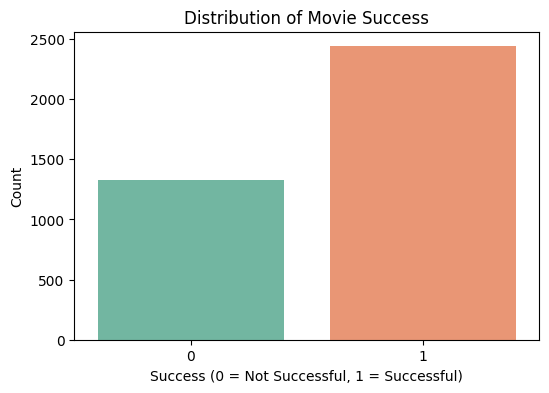

In [9]:
# Step 1: Check target variable distribution
print("Target variable distribution:")
if "success" in df.columns:
    target_dist = df["success"].value_counts(dropna=False).sort_index()
    print(target_dist)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x="success", hue="success", palette="Set2", legend=False)
    plt.title("Distribution of Movie Success")
    plt.xlabel("Success (0 = Not Successful, 1 = Successful)")
    plt.ylabel("Count")
    plt.show()
else:
    print("Column 'success' not found in dataset.")

In [10]:
# Step 2: Summarize feature means by success class
if "success" in df.columns:
    summary_cols = [col for col in ["budget", "revenue", "profit", "roi", "popularity", "vote_average"] if col in df.columns]
    class_summary = df.groupby("success")[summary_cols].mean().round(2)
    print("Average feature values by success class:")
    display(class_summary)
else:
    print("Class summary skipped because 'success' is missing.")

Average feature values by success class:


,budget,revenue,profit,roi,popularity,vote_average
success,,,,,,
0,25533777.16,1.048106e+07,-1.505271e+07,-0.71,10.83,5.85
1,43345408.35,1.548879e+08,1.115424e+08,3912.35,34.25,6.43


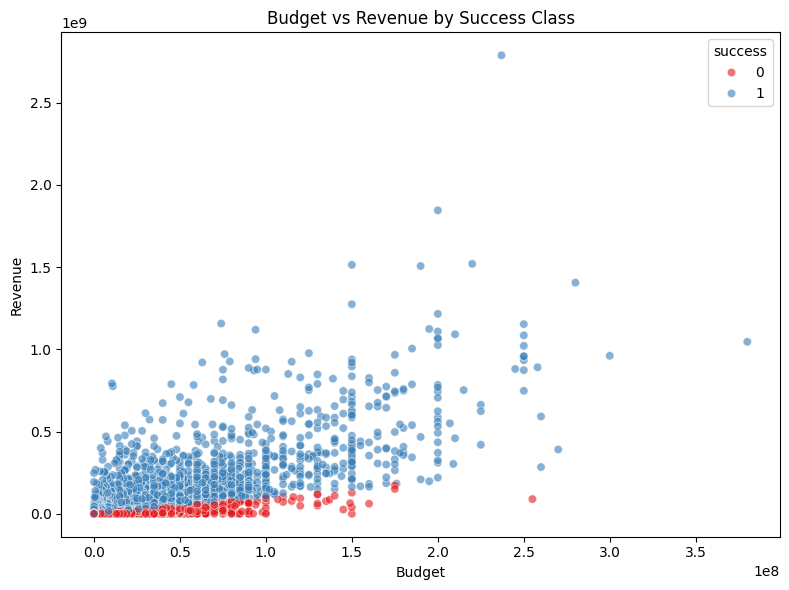

In [11]:
# Step 3: Budget vs revenue relationship by success class
required_scatter_cols = ["budget", "revenue", "success"]
if all(col in df.columns for col in required_scatter_cols):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="budget", y="revenue", hue="success", alpha=0.6, palette="Set1")
    plt.title("Budget vs Revenue by Success Class")
    plt.xlabel("Budget")
    plt.ylabel("Revenue")
    plt.tight_layout()
    plt.show()
else:
    print("Scatter plot skipped because required columns are missing.")

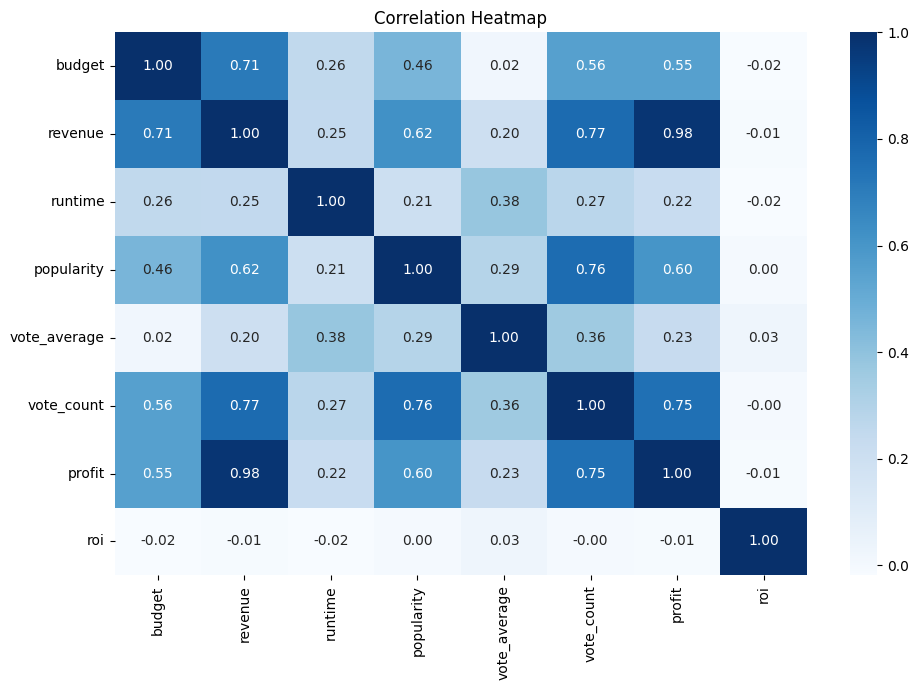

In [12]:
# Step 4: Correlation heatmap for numeric variables
numeric_features = ["budget", "revenue", "runtime", "popularity", "vote_average", "vote_count", "profit", "roi"]
available_numeric = [col for col in numeric_features if col in df.columns]

if available_numeric:
    corr = df[available_numeric].corr(numeric_only=True)
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", square=False)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Correlation skipped because numeric columns are missing.")

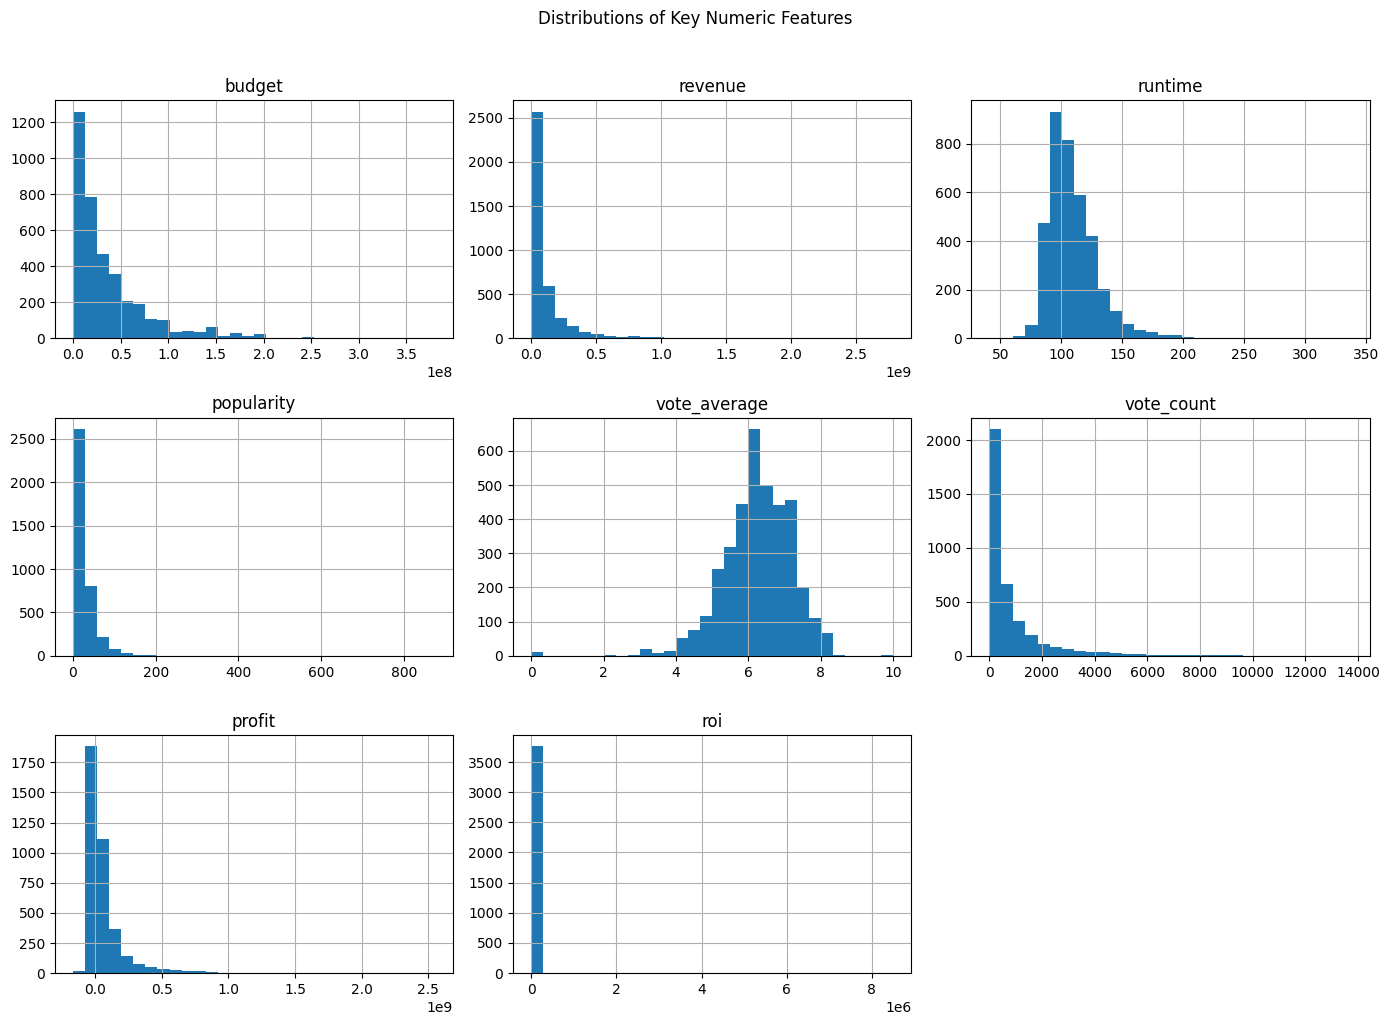

In [13]:
# Step 5: Inspect distributions of key numeric features
numeric_features = ["budget", "revenue", "runtime", "popularity", "vote_average", "vote_count", "profit", "roi"]
available_numeric = [col for col in numeric_features if col in df.columns]

if available_numeric:
    df[available_numeric].hist(figsize=(14, 10), bins=30)
    plt.suptitle("Distributions of Key Numeric Features", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No expected numeric feature columns were found.")

In [14]:
# Compare mean and median for revenue and budget
summary_stats = pd.DataFrame(
    {
        "mean": [df["revenue"].mean(), df["budget"].mean()],
        "median": [df["revenue"].median(), df["budget"].median()],
    },
    index=["revenue", "budget"],
).round(2)

print("Mean and median comparison:")
display(summary_stats)

Mean and median comparison:


,mean,median
revenue,1.040653e+08,38974178.0
budget,3.707677e+07,23000000.0


In [15]:
# Calculate variance and standard deviation for revenue
revenue_dispersion = pd.Series(
    {
        "variance": df["revenue"].var(),
        "standard_deviation": df["revenue"].std(),
    }
).round(2)

print("Revenue dispersion statistics:")
display(revenue_dispersion.to_frame(name="value"))

Revenue dispersion statistics:


,value
variance,3.157799e+16
standard_deviation,1.777020e+08


---